# Predikcija prodajne cene nekretnina (KT1)

Ovaj notebook prikazuje ceo tok rada na projektu, na manjem broju jasnih koraka:

1. Učitavanje podataka i kratka EDA
2. Čišćenje i priprema skupa (`src/cleaning.py`)
3. (Opcionalno) Geokodiranje i geo obeležja (`src/geo.py`, uz cache)
4. Trening i poređenje Random Forest i XGBoost (`src/modeling.py`)
5. Evaluacija (MAE, RMSE, MAPE, R²) i osnovni grafici
6. Interpretabilnost (feature importance i opcionalno SHAP)

Većina logike je u Python modulima u folderu `src/`, a notebook ih samo poziva.


## 1) Setup (imports, putanje, verzije biblioteka)

In [1]:
import sys
from pathlib import Path
import platform

# Project root: pokreni notebook iz root-a repozitorijuma (gde je folder `src/`)
project_root = Path('.').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print('python:', platform.python_version())

# Osnovne biblioteke
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ML
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('pandas:', pd.__version__)
print('numpy:', np.__version__)
print('scikit-learn:', sklearn.__version__)

# Optional (ako nisu instalirani, notebook i dalje može da radi bez njih)
try:
    import xgboost
    print('xgboost:', xgboost.__version__)
except Exception as e:
    print('xgboost not available:', e)

try:
    import shap
    print('shap:', shap.__version__)
except Exception as e:
    print('shap not available:', e)


python: 3.9.0
pandas: 2.3.3
numpy: 2.0.2
scikit-learn: 1.5.2
xgboost: 2.1.4


c:\Users\milin\Desktop\siap_real_estate_price_prediction\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap: 0.49.1


## 2) Konfiguracija (ulazni fajl, uključivanje težih koraka)

In [2]:
# Putanja do raw dataseta (prilagodi po potrebi)
DATASET_PATH = Path('data/raw/listings.csv')

# Kontrola koraka
RUN_GEOCODING = False      # True ako želiš da dodaš dist_to_center_km (koristi cache ako postoji)
DO_TRAIN = True           # True ako želiš da treniraš u notebooku (sporije)
DO_SHAP = True           # SHAP zna da traje; uključi samo ako imaš vremena

# Brži trening (ako DO_TRAIN=True)
TRAIN_N_ITER_SEARCH = 10   # 5-10 za KT1; veće vrednosti duže traju


## 3) Učitavanje podataka i brza validacija šeme

In [3]:
from IPython.display import display
from src.config import SchemaConfig, get_paths

schema = SchemaConfig()
paths = get_paths(project_root)

df_raw = pd.read_csv(DATASET_PATH)

print('rows:', len(df_raw), '| cols:', df_raw.shape[1])
display(df_raw.head(5))

# Brza provera: da li ključne kolone postoje
required = [
    schema.target_col,
    schema.area_col,
    schema.floor_col,
    schema.location_col,
]
missing_cols = [c for c in required if c not in df_raw.columns]
print('missing required cols:', missing_cols)

# Missing-rate
missing_rate = df_raw.isna().mean().sort_values(ascending=False)
display(missing_rate.head(20))


rows: 9619 | cols: 10


,Price_EUR,Square_footage,Number_of_rooms,State,Lift,Heating,Optical_internet,Parking,Floor,Street
0,135000.0,37 m²,2.0,Standardna gradnja,1,NaN,0,0,0,Žarkovo
1,189000.0,83 m²,3.0,Izvorno stanje,1,"Centralno grejanje, Klima uređaj",0,1,4,Miljakovac I
2,174500.0,63 m²,3.0,Novogradnja,0,Etažno grejanje na gas,0,0,3,Karaburma
3,170000.0,61 m²,3.0,Novogradnja,1,Centralno grejanje,0,1,0,Zvezdara
4,135000.0,73 m²,3.0,Novogradnja,0,Ostalo,0,1,3,Krnjača


missing required cols: []


Heating             0.082129
State               0.016842
Number_of_rooms     0.013203
Price_EUR           0.004470
Square_footage      0.001663
Lift                0.000000
Optical_internet    0.000000
Parking             0.000000
Floor               0.000000
Street              0.000000
dtype: float64

## 4) Brzi parsing i EDA (površina, sprat, cena)

price (raw):


count    9.576000e+03
mean     2.272177e+07
std      1.653631e+09
min      1.000000e+03
25%      1.499648e+05
50%      2.295000e+05
75%      3.426528e+05
max      1.470304e+11
Name: Price_EUR, dtype: float64

area_m2_parsed (raw):


count      9603.000000
mean        103.307559
std        1440.199202
min           1.000000
25%          53.000000
50%          70.000000
75%          99.000000
max      128000.000000
Name: area_m2_parsed, dtype: float64

floor_parsed (top):


floor_parsed
 1.0     1616
 0.0     1525
 2.0     1329
 3.0     1307
 4.0      979
 5.0      791
 0.5      479
 6.0      457
 7.0      313
 8.0      198
-1.0      133
 9.0       89
 10.0      77
 12.0      52
 11.0      45
Name: count, dtype: int64

EDA filter: kept 9397/9619 rows, removed 222 outliers for visualization.
Caps used: price<=P99=1,350,000 EUR, area<=P99=254 m²


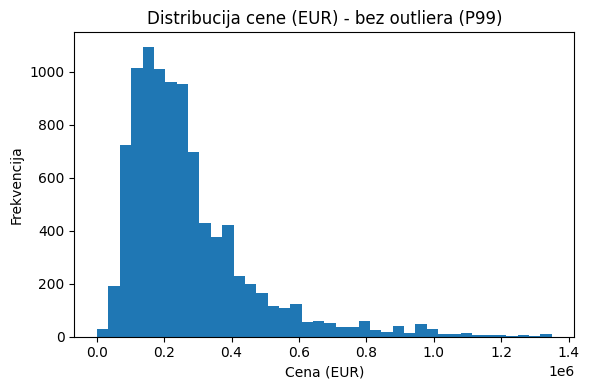

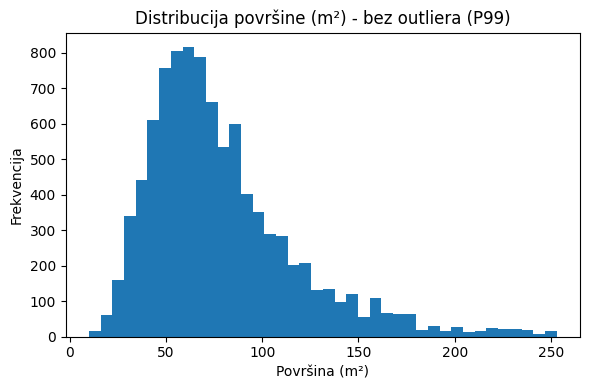

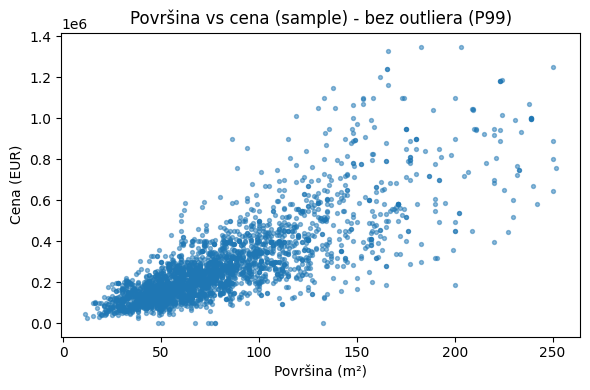

,Price_EUR,area_m2_parsed,Square_footage,Floor
7811,1.470304e+11,125.00,125 m²,7
8422,6.760032e+10,65.29,65.29 m²,1
7546,4.250450e+07,46.35,46.35 m²,0
7638,3.093343e+07,NaN,NaN,0
7561,2.700320e+07,NaN,NaN,4


In [4]:
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.cleaning import parse_area_m2, parse_floor

df = df_raw.copy()

# Privremene kolone za EDA
df["area_m2_parsed"] = df[schema.area_col].apply(parse_area_m2)
df["floor_parsed"] = df[schema.floor_col].apply(parse_floor)

# Osnovne statistike (RAW)
print("price (raw):")
display(df[schema.target_col].describe())

print("area_m2_parsed (raw):")
display(df["area_m2_parsed"].describe())

print("floor_parsed (top):")
display(df["floor_parsed"].value_counts(dropna=False).head(15))

# -----------------------------
# Vizuelna EDA bez ekstremnih outliera (P99)
# -----------------------------
price = df[schema.target_col]
area = df["area_m2_parsed"]

price_p99 = price.quantile(0.99)
area_p99 = area.quantile(0.99)

MIN_PRICE_EUR = 1000
MIN_AREA_M2 = 10

mask_ok = (
    price.notna()
    & area.notna()
    & (price >= MIN_PRICE_EUR)
    & (area >= MIN_AREA_M2)
    & (price <= price_p99)
    & (area <= area_p99)
)

n_total = len(df)
n_ok = int(mask_ok.sum())
n_out = n_total - n_ok

print(f"EDA filter: kept {n_ok}/{n_total} rows, removed {n_out} outliers for visualization.")
print(f"Caps used: price<=P99={price_p99:,.0f} EUR, area<=P99={area_p99:,.0f} m²")

df_eda = df.loc[mask_ok].copy()

# Distribucija cene (EDA)
plt.figure(figsize=(6, 4))
df_eda[schema.target_col].plot(kind="hist", bins=40)
plt.title("Distribucija cene (EUR) - bez outliera (P99)")
plt.xlabel("Cena (EUR)")
plt.ylabel("Frekvencija")
plt.tight_layout()
plt.show()

# Distribucija površine (EDA)
plt.figure(figsize=(6, 4))
df_eda["area_m2_parsed"].plot(kind="hist", bins=40)
plt.title("Distribucija površine (m²) - bez outliera (P99)")
plt.xlabel("Površina (m²)")
plt.ylabel("Frekvencija")
plt.tight_layout()
plt.show()

# Scatter (sample) - bez outliera (EDA)
tmp = df_eda[[schema.target_col, "area_m2_parsed"]].dropna()
if len(tmp) > 0:
    sample = tmp.sample(n=min(3000, len(tmp)), random_state=42)
    plt.figure(figsize=(6, 4))
    plt.scatter(sample["area_m2_parsed"], sample[schema.target_col], s=8, alpha=0.5)
    plt.title("Površina vs cena (sample) - bez outliera (P99)")
    plt.xlabel("Površina (m²)")
    plt.ylabel("Cena (EUR)")
    plt.tight_layout()
    plt.show()

# (Opcionalno) prikaži top outliere
df_out = df.loc[~mask_ok, [schema.target_col, "area_m2_parsed", schema.area_col, schema.floor_col]].copy()
display(df_out.sort_values(by=schema.target_col, ascending=False).head(5))

## 5) Čišćenje i priprema skupa (`clean_dataset`)

In [5]:
from src.cleaning import clean_dataset

cleaned, cleaning_report = clean_dataset(
    df_raw,
    target_col=schema.target_col,
    area_col_raw=schema.area_col,
    rooms_col=schema.rooms_col,
    state_col=schema.state_col,
    lift_col=schema.lift_col,
    heating_col=schema.heating_col,
    optical_col=schema.optical_col,
    parking_col=schema.parking_col,
    floor_col=schema.floor_col,
    location_col=schema.location_col,
)

print('Cleaning report (ključne brojke):')
try:
    display(pd.DataFrame([cleaning_report.to_dict()]))
except Exception:
    print(cleaning_report)

print('Cleaned rows:', len(cleaned), '| cols:', cleaned.shape[1])
display(cleaned.head(5))

# Snimi processed CSV (korisno i za brži trening)
paths.data_processed.mkdir(parents=True, exist_ok=True)
processed_path = paths.data_processed / 'cleaned_from_notebook.csv'
cleaned.to_csv(processed_path, index=False)
print('Saved cleaned to:', processed_path)


Cleaning report (ključne brojke):


,initial_rows,dropped_missing_target,dropped_missing_area,dropped_invalid_target,dropped_invalid_area,dropped_outliers,rental_like_filtered
0,9619,43,11,0,0,153,25


Cleaned rows: 9387 | cols: 21


,Price_EUR,Square_footage,Number_of_rooms,State,Lift,Heating,Optical_internet,Parking,Floor,Street,...,rooms,floor,lift,parking,optical_internet,state,street_raw,street,heating_was_missing,heating
0,135000.0,37 m²,2.0,Standardna gradnja,1,NaN,0,0,0,Žarkovo,...,2.0,0.0,1,0,0,Standardna gradnja,Žarkovo,Žarkovo,1,centralno grejanje
1,189000.0,83 m²,3.0,Izvorno stanje,1,"Centralno grejanje, Klima uređaj",0,1,4,Miljakovac I,...,3.0,4.0,1,1,0,Izvorno stanje,Miljakovac I,Miljakovac I,0,"centralno grejanje, klima uređaj"
2,174500.0,63 m²,3.0,Novogradnja,0,Etažno grejanje na gas,0,0,3,Karaburma,...,3.0,3.0,0,0,0,Novogradnja,Karaburma,Karaburma,0,etažno grejanje na gas
3,170000.0,61 m²,3.0,Novogradnja,1,Centralno grejanje,0,1,0,Zvezdara,...,3.0,0.0,1,1,0,Novogradnja,Zvezdara,Zvezdara,0,centralno grejanje
4,135000.0,73 m²,3.0,Novogradnja,0,Ostalo,0,1,3,Krnjača,...,3.0,3.0,0,1,0,Novogradnja,Krnjača,Krnjača,0,ostalo


Saved cleaned to: C:\Users\milin\Desktop\siap_real_estate_price_prediction\data\processed\cleaned_from_notebook.csv


## 6) (Opcionalno) Geokodiranje + geo-features (sa cache-om)

In [6]:
if RUN_GEOCODING:
    from src.config import GeoConfig
    from src.geo import add_geo_features

    geo_cfg = GeoConfig()
    paths.geo_cache.mkdir(parents=True, exist_ok=True)

    cleaned_geo = add_geo_features(
        cleaned,
        location_col='street',  # koristimo normalizovanu lokaciju iz clean_dataset
        cache_path=paths.geo_cache / 'geocoded.csv',
        user_agent=geo_cfg.user_agent,
        city_hint=geo_cfg.city_hint,
        country_hint=geo_cfg.country_hint,
        delay_seconds=geo_cfg.request_delay_seconds,
        center_lat=geo_cfg.center_lat,
        center_lon=geo_cfg.center_lon,
    )

    geo_path = paths.data_processed / 'cleaned_with_geo_from_notebook.csv'
    cleaned_geo.to_csv(geo_path, index=False)
    print('Geocoding finished, saved to:', geo_path)

    cleaned = cleaned_geo  # dalje radimo sa obogaćenim skupom
else:
    print('Skipping geocoding (RUN_GEOCODING=False)')


Skipping geocoding (RUN_GEOCODING=False)


## 7) Trening i poređenje modela (RF vs XGBoost)

,MAE,RMSE,MAPE_%,R2
RandomForest,45214.912711,89281.413193,16.309901,0.824368
XGBoost,43712.360215,86390.524543,15.239366,0.835558


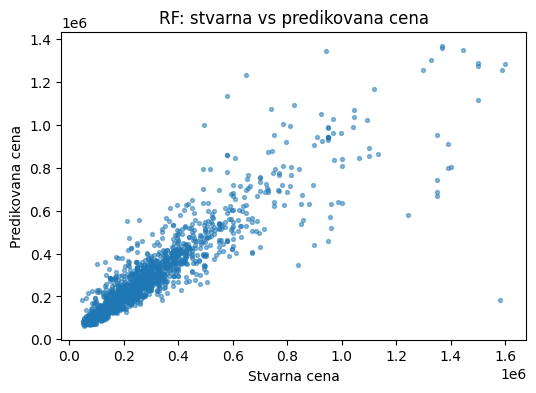

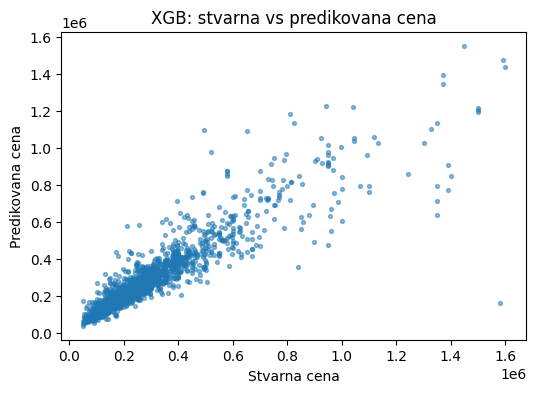

Saved pipelines to: C:\Users\milin\Desktop\siap_real_estate_price_prediction\models


In [7]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.clip(np.abs(y_true), 1e-9, None)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100.0

if DO_TRAIN:
    from src.config import TrainConfig
    from src.modeling import train_models, save_pipeline

    train_cfg = TrainConfig()

    artifacts, debug = train_models(
        cleaned,
        target_col=schema.target_col,
        random_seed=train_cfg.random_seed,
        test_size=train_cfg.test_size,
        cv_folds=train_cfg.cv_folds,
        n_iter_search=TRAIN_N_ITER_SEARCH,
    )

        # Evaluacija: stratifikovana podela po cenovnim binovima (isto kao u train_models)
    X = cleaned.drop(columns=[schema.target_col])
    y = cleaned[schema.target_col]

    try:
        strat = pd.qcut(y, q=10, duplicates="drop")
    except Exception:
        strat = None

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=train_cfg.test_size,
        random_state=train_cfg.random_seed,
        stratify=strat
    )

    y_pred_rf = artifacts.rf_pipeline.predict(X_test)
    y_pred_xgb = artifacts.xgb_pipeline.predict(X_test)

    metrics = pd.DataFrame({
        'MAE': [mean_absolute_error(y_test, y_pred_rf), mean_absolute_error(y_test, y_pred_xgb)],
        'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred_rf)), np.sqrt(mean_squared_error(y_test, y_pred_xgb))],
        'MAPE_%': [mape(y_test, y_pred_rf), mape(y_test, y_pred_xgb)],
        'R2': [r2_score(y_test, y_pred_rf), r2_score(y_test, y_pred_xgb)],
    }, index=['RandomForest', 'XGBoost'])

    display(metrics)

    # Grafici: stvarna vs predikovana
    plt.figure(figsize=(6,4))
    plt.scatter(y_test, y_pred_rf, s=8, alpha=0.5)
    plt.title('RF: stvarna vs predikovana cena')
    plt.xlabel('Stvarna cena')
    plt.ylabel('Predikovana cena')
    plt.show()

    plt.figure(figsize=(6,4))
    plt.scatter(y_test, y_pred_xgb, s=8, alpha=0.5)
    plt.title('XGB: stvarna vs predikovana cena')
    plt.xlabel('Stvarna cena')
    plt.ylabel('Predikovana cena')
    plt.show()

    # Sačuvaj modele
    paths.models.mkdir(parents=True, exist_ok=True)
    save_pipeline(artifacts.rf_pipeline, str(paths.models / 'rf_pipeline_from_notebook.joblib'))
    save_pipeline(artifacts.xgb_pipeline, str(paths.models / 'xgb_pipeline_from_notebook.joblib'))
    print('Saved pipelines to:', paths.models)

else:
    # Brzi prikaz postojećih rezultata (ako si ranije pokrenuo run_train.py)
    from pathlib import Path
    import json
    from IPython.display import Image, display

    metrics_path = paths.reports / "metrics.json"
    if metrics_path.exists():
        metrics_json = json.loads(metrics_path.read_text(encoding="utf-8"))
        rf = metrics_json.get("random_forest", {})
        xgb = metrics_json.get("xgboost", {})
        display(pd.DataFrame([rf, xgb], index=["RandomForest", "XGBoost"]))
        print("Loaded:", metrics_path)
    else:
        print("No metrics.json found in reports/. Set DO_TRAIN=True to train inside notebook or run: python run_train.py")

    # Prikaži postojeće plotove ako postoje
    for img_name in ["actual_vs_pred_xgb.png", "residuals_xgb.png"]:
        p = paths.reports / img_name
        if p.exists():
            display(Image(filename=str(p)))


## 8) Interpretabilnost (feature importance + opcionalno SHAP)

,rank,feature_group,rf_importance_sum
0,1,area_m2,0.634596
1,2,rooms,0.061235
2,3,floor,0.032701
3,4,heating,0.018342
4,5,state,0.014987
5,6,lift,0.008315
6,7,parking,0.003977
7,8,optical_internet,0.000885


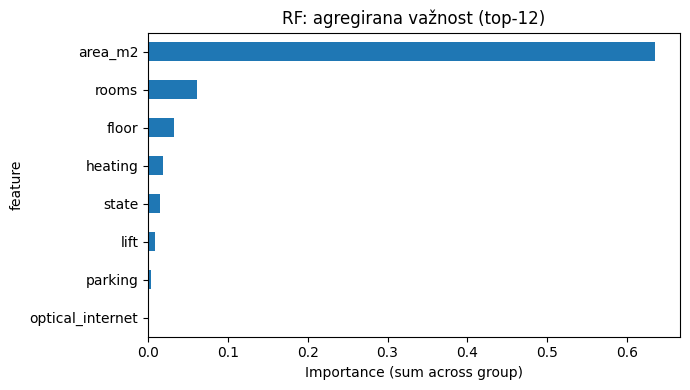

,rank,feature,mean_abs_shap_eur
0,1,area_m2,103267.765625
1,2,street,79793.921875
2,3,"heating_klima uređaj, podno grejanje, toplotna...",78268.609375
3,4,"heating_etažno grejanje na gas, podno grejanje",47447.335938
4,5,"heating_centralno grejanje, podno grejanje",46791.273438
5,6,"heating_podno grejanje, ostalo",33323.984375
6,7,"heating_klima uređaj, kamin",30105.275391
7,8,"heating_centralno grejanje, kamin",29484.773438
8,9,"heating_klima uređaj, etažno grejanje na gas, ...",22415.060547
9,10,heating_kamin,22046.828125


c:\Users\milin\Desktop\siap_real_estate_price_prediction\.venv\lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


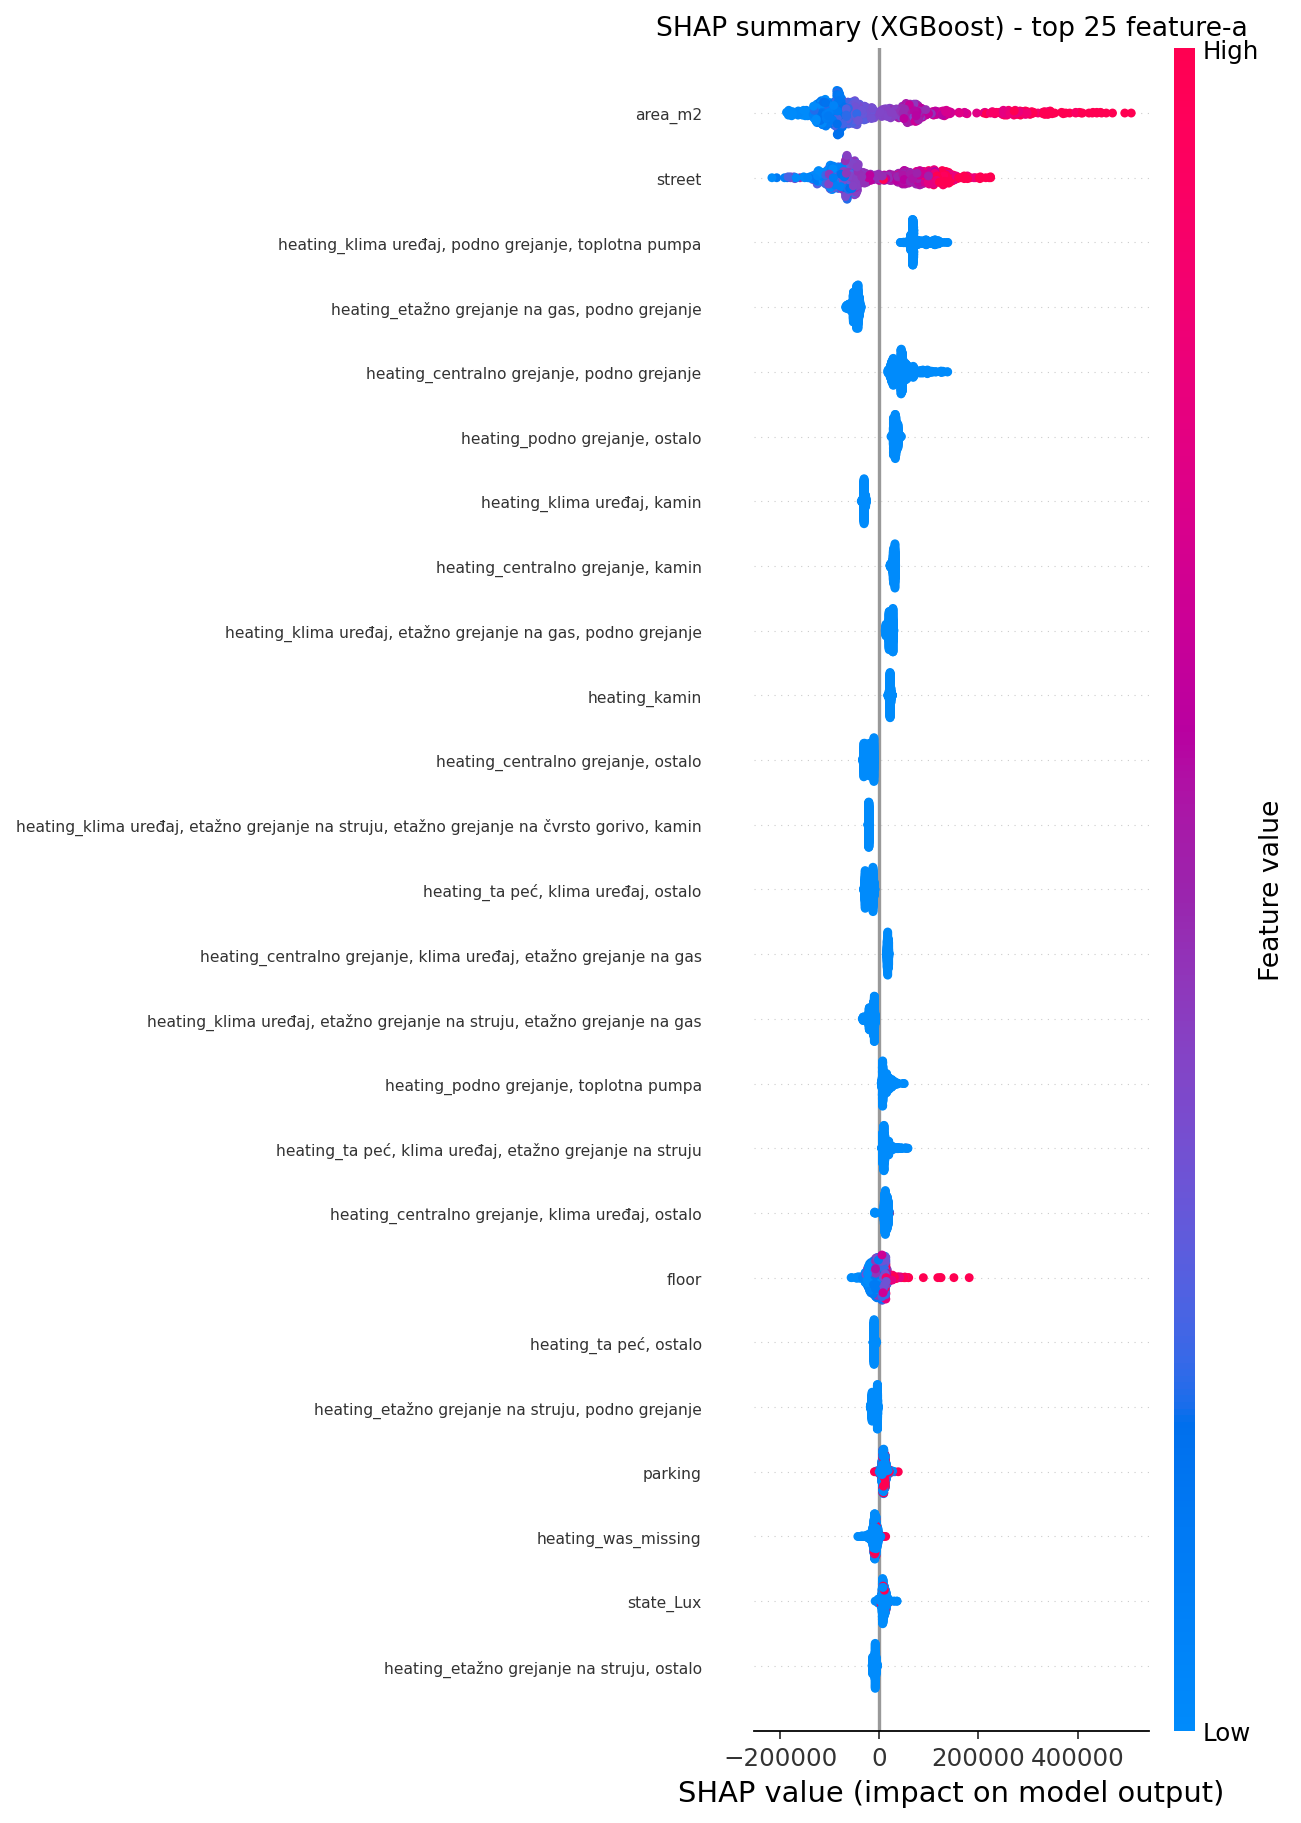

In [8]:
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _get_preprocess_and_model(pipeline):
    pre = None
    for k in ["preprocess", "preprocessor"]:
        if k in pipeline.named_steps:
            pre = pipeline.named_steps[k]
            break

    mdl = None
    for k in ["model", "regressor", "estimator"]:
        if k in pipeline.named_steps:
            mdl = pipeline.named_steps[k]
            break
    return pre, mdl

def _safe_feature_names(pre, n_fallback):
    try:
        return np.array(pre.get_feature_names_out(), dtype=object)
    except Exception:
        return np.array([f"f{i}" for i in range(n_fallback)], dtype=object)

def _group_name(feat: str) -> str:
    # group some high-cardinality prefixes for RF importance readability
    if feat.startswith("heating_"):
        return "heating"
    if feat.startswith("state_"):
        return "state"
    if feat.startswith("street"):
        return "street"
    return feat

def _aggregate_importance(names, values, drop_groups=None):
    s = pd.Series(values, index=pd.Index(names, name="feature"))
    s.index = s.index.map(_group_name)
    if drop_groups:
        s = s[~s.index.isin(drop_groups)]
    return s.groupby(level=0).sum().sort_values(ascending=False)

def _rank_table(series: pd.Series, col_name: str, top_k: int):
    t = series.head(top_k).reset_index()
    t.columns = ["feature_group", col_name]
    t.insert(0, "rank", np.arange(1, len(t) + 1))
    return t

TOP_K_RF = 12
TOP_N_SHAP = 25
DROP_GROUPS_RF = {"street"}  # hide street in RF aggregated plot (optional)

if not DO_TRAIN:
    print("DO_TRAIN=False -> nema interpretabilnosti iz notebook-a. Postavi DO_TRAIN=True i rerun.")
else:
    pre_rf, mdl_rf = _get_preprocess_and_model(artifacts.rf_pipeline)
    pre_xgb, mdl_xgb = _get_preprocess_and_model(artifacts.xgb_pipeline)

    # -------------------------
    # RF: aggregated importance
    # -------------------------
    if mdl_rf is not None and hasattr(mdl_rf, "feature_importances_") and pre_rf is not None:
        X = cleaned.drop(columns=[schema.target_col])
        X_trans = pre_rf.transform(X.head(2000))

        names = _safe_feature_names(pre_rf, X_trans.shape[1])
        rf_imp = _aggregate_importance(names, mdl_rf.feature_importances_, drop_groups=DROP_GROUPS_RF)

        display(_rank_table(rf_imp, "rf_importance_sum", TOP_K_RF))

        plt.figure(figsize=(7, 4))
        rf_imp.head(TOP_K_RF)[::-1].plot(kind="barh")
        plt.title(f"RF: agregirana važnost (top-{TOP_K_RF})")
        plt.xlabel("Importance (sum across group)")
        plt.tight_layout()
        plt.show()
    else:
        print("RF importance nije dostupna (nema feature_importances_ ili preprocess).")

    # -------------------------
    # XGB: SHAP (detailed table + beeswarm)
    # -------------------------
    if DO_SHAP and mdl_xgb is not None and pre_xgb is not None:
        import shap

        X = cleaned.drop(columns=[schema.target_col])
        X_sample = X.sample(n=min(1000, len(X)), random_state=42)
        X_trans = pre_xgb.transform(X_sample)

        # sparse -> dense (stabilnije za SHAP)
        try:
            import scipy
            if scipy.sparse.issparse(X_trans):
                X_trans = X_trans.toarray()
        except Exception:
            pass

        # feature names
        feature_names = _safe_feature_names(pre_xgb, X_trans.shape[1]).tolist()

        explainer = shap.TreeExplainer(mdl_xgb)
        shap_values = explainer.shap_values(X_trans)

        # tabela: top feature-i po mean(|SHAP|) u EUR
        mean_abs = np.mean(np.abs(shap_values), axis=0)
        shap_rank = (
            pd.DataFrame({"feature": feature_names, "mean_abs_shap_eur": mean_abs})
            .sort_values("mean_abs_shap_eur", ascending=False)
            .reset_index(drop=True)
        )
        shap_rank.insert(0, "rank", shap_rank.index + 1)
        display(shap_rank.head(25))

        # beeswarm: čitljiv top-N
        plt.figure(figsize=(10, 7), dpi=160)
        shap.summary_plot(
            shap_values,
            X_trans,
            feature_names=feature_names,
            max_display=TOP_N_SHAP,
            show=False
        )
        plt.gca().tick_params(axis="y", labelsize=7)
        plt.title(f"SHAP summary (XGBoost) - top {TOP_N_SHAP} feature-a")
        plt.tight_layout()
        plt.show()
    else:
        print("DO_SHAP=False ili XGB pipeline nije dostupan -> preskačem SHAP.")

## 9) Izlazni fajlovi (šta se kreira)


- `data/processed/cleaned_from_notebook.csv` (čišćen skup nakon `clean_dataset`)
- `data/processed/cleaned_with_geo_from_notebook.csv` (ako je uključeno geokodiranje)
- `models/rf_pipeline_from_notebook.joblib` i `models/xgb_pipeline_from_notebook.joblib` (ako je uključen trening)
- `reports/metrics.json`, `reports/importance_*.png`, `reports/actual_vs_pred_xgb.png`, `reports/residuals_xgb.png` (ako si ranije pokrenuo `run_train.py`)

Ako želiš da sve ponovo generišeš iz terminala (bez notebooka), koristi `run_eda.py` i `run_train.py`.
